# Task 2 — Heritage Crack Detection (v2)

**Model:** YOLOv8l — 3-phase progressive training  
**Data:** OmniCrack30K + DACL10K crack class (co-training, optional)  
**Key fixes:** box quality filtering, consistent 640px, 130 total epochs, SAHI inference  
**Target:** mAP@50 > 0.70  

**Runtime:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [1]:
import torch
assert torch.cuda.is_available(), 'No GPU — Runtime > Change runtime type > T4 GPU'
print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU  : Tesla T4
VRAM : 15.6 GB


In [2]:
!pip install -q ultralytics sahi ensemble-boxes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.6 MB/s eta 0:00:00


## 1. Mount Drive & Paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_DIR  = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR   = Path('/content/data')
DRIVE_CKPT = DRIVE_DIR / 'checkpoints' / 'detector_v2'
DRIVE_CKPT.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

USE_DACL10K = True  # set False to skip DACL10K co-training (faster but lower ceiling)

print('Drive contents:', sorted(f.name for f in DRIVE_DIR.iterdir()))

Mounted at /content/drive
Drive contents: ['checkpoints', 'crackforest.zip', 'cross_eval', 'dacl10k_best.pt', 'degradation_analysis', 'failure_analysis', 'historical_crack.zip', 'masonry.zip', 'notebooks', 'omnicrack30k.zip', 'plots', 'samples']


## 2. Extract OmniCrack30K

In [4]:
import zipfile, shutil

OMNI_DIR = DATA_DIR / 'omnicrack30k'

if OMNI_DIR.exists() and any(OMNI_DIR.rglob('*.jpg')):
    print('OmniCrack30K already extracted.')
else:
    zip_src   = DRIVE_DIR / 'omnicrack30k.zip'
    zip_local = Path('/content/omnicrack30k.zip')
    if not zip_local.exists():
        print(f'Copying {zip_src.stat().st_size/1e9:.1f} GB zip to local...')
        shutil.copy2(zip_src, zip_local)
        print('Copy done.')
    print('Unzipping...')
    with zipfile.ZipFile(zip_local, 'r') as zf:
        zf.extractall(DATA_DIR)
    if not OMNI_DIR.exists():
        OMNI_DIR.mkdir()
        for item in ['images', 'annotations', 'centerlines']:
            src = DATA_DIR / item
            if src.exists():
                shutil.move(str(src), str(OMNI_DIR / item))
    print('Done.')

print(f'Contents: {[p.name for p in sorted(OMNI_DIR.iterdir())]}')

Copying 10.6 GB zip to local...
Copy done.
Unzipping...
Done.
Contents: ['annotations', 'centerlines', 'images']


## 3. DACL10K Crack Subset (co-training)

Downloads DACL10K from AWS (~4.8 GB), extracts only crack/ACrack annotations.
Set `USE_DACL10K = False` above to skip.

In [5]:
import subprocess, json as _json

DACL_DIR      = DATA_DIR / 'dacl10k_v2_devphase'
DACL_YOLO_DIR = DATA_DIR / 'dacl10k_crack'
dacl_pairs    = []  # (img_path, lbl_path) for training

if not USE_DACL10K:
    print('USE_DACL10K=False — skipping.')
elif (DACL_YOLO_DIR / 'images').exists() and any((DACL_YOLO_DIR / 'images').rglob('*.jpg')):
    print('DACL10K crack subset already prepared.')
    dacl_pairs = [(p, DACL_YOLO_DIR / 'labels' / p.with_suffix('.txt').name)
                  for p in sorted((DACL_YOLO_DIR / 'images').glob('*.jpg'))]
    print(f'  {len(dacl_pairs)} crack images.')
else:
    dacl_zip = DATA_DIR / 'dacl10k_v2_devphase.zip'
    if not DACL_DIR.exists():
        if not dacl_zip.exists():
            print('Downloading DACL10K from AWS (~4.8 GB)...')
            subprocess.run([
                'wget', '-q', '--show-progress',
                'https://dacl10k.s3.eu-central-1.amazonaws.com/dacl10k-challenge/dacl10k_v2_devphase.zip',
                '-O', str(dacl_zip)
            ], check=True)
        print('Extracting DACL10K...')
        with zipfile.ZipFile(dacl_zip) as zf:
            zf.extractall(DATA_DIR)
        print('Done.')

    CRACK_LABELS = {'Crack', 'ACrack'}
    (DACL_YOLO_DIR / 'images').mkdir(parents=True, exist_ok=True)
    (DACL_YOLO_DIR / 'labels').mkdir(parents=True, exist_ok=True)

    n_imgs = n_boxes = 0
    for ann_path in sorted((DACL_DIR / 'annotations' / 'train').glob('*.json')):
        ann   = _json.loads(ann_path.read_text())
        img_w = ann['imageWidth']
        img_h = ann['imageHeight']
        lines = []
        for shape in ann['shapes']:
            if shape['label'] not in CRACK_LABELS:
                continue
            pts = shape['points']
            xs  = [p[0] for p in pts]
            ys  = [p[1] for p in pts]
            x1, x2 = max(0, min(xs)), min(img_w, max(xs))
            y1, y2 = max(0, min(ys)), min(img_h, max(ys))
            bw = (x2 - x1) / img_w
            bh = (y2 - y1) / img_h
            if bw < 0.005 or bh < 0.005:
                continue
            if bw * bh > 0.40:
                continue  # spanning annotation, skip
            cx = (x1 + x2) / 2 / img_w
            cy = (y1 + y2) / 2 / img_h
            lines.append(f'0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')
        if not lines:
            continue
        src_img = DACL_DIR / 'images' / 'train' / ann['imageName']
        if not src_img.exists():
            continue
        dst_img = DACL_YOLO_DIR / 'images' / ann['imageName']
        dst_lbl = DACL_YOLO_DIR / 'labels' / (Path(ann['imageName']).stem + '.txt')
        shutil.copy2(src_img, dst_img)
        dst_lbl.write_text('\n'.join(lines))
        dacl_pairs.append((dst_img, dst_lbl))
        n_imgs += 1
        n_boxes += len(lines)

    print(f'DACL10K crack subset: {n_imgs} images, {n_boxes} boxes')

Extracting DACL10K...
Done.
DACL10K crack subset: 1800 images, 3319 boxes


## 4. Setup Splits & Improved Label Conversion

In [6]:
import cv2, numpy as np
from tqdm.notebook import tqdm

IMG_ROOT = OMNI_DIR / 'images'
ANN_ROOT = OMNI_DIR / 'annotations'
EXTS     = {'.jpg', '.jpeg', '.png', '.bmp'}
SPLITS   = ['training', 'validation', 'test']

split_imgs = {}
for split in SPLITS:
    imgs = sorted([p for p in (IMG_ROOT / split).rglob('*')
                   if p.suffix.lower() in EXTS and p.is_file()])
    split_imgs[split] = imgs
    print(f'{split:12}: {len(imgs)} images')

mask_lookup = {
    p.stem: p
    for split in SPLITS
    for p in (ANN_ROOT / split).rglob('*')
    if p.suffix.lower() in EXTS and p.is_file()
}
print(f'Masks found: {len(mask_lookup)}')

training    : 22158 images
validation  : 3277 images
test        : 4582 images
Masks found: 29884


In [7]:
def mask_to_yolo_labels(mask_path, min_area=200, max_area_frac=0.40, max_ar=8.0):
    """Convert binary mask to YOLO bbox labels.
    Filters: spanning boxes (>40% image), extreme aspect ratio (>8:1), tiny blobs.
    """
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w  = mask.shape
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    labels = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        bw_n = bw / w
        bh_n = bh / h
        if bw_n * bh_n > max_area_frac:
            continue  # spanning crack — box covers too much image
        if max(bw_n / (bh_n + 1e-6), bh_n / (bw_n + 1e-6)) > max_ar:
            continue  # extreme aspect ratio — unlearnable
        cx = (x + bw / 2) / w
        cy = (y + bh / 2) / h
        labels.append(f'0 {cx:.6f} {cy:.6f} {min(bw_n,1.):.6f} {min(bh_n,1.):.6f}')
    return labels


LBL_DIR     = OMNI_DIR / 'labels'
already_done = all(
    (LBL_DIR / s).exists() and len(list((LBL_DIR / s).glob('*.txt'))) > 100
    for s in SPLITS
)

if already_done:
    print(f'Labels already exist, skipping conversion.')
else:
    print('Converting masks to YOLO labels (with quality filtering)...')
    total_boxes = 0
    for split in SPLITS:
        split_lbl_dir = LBL_DIR / split
        split_lbl_dir.mkdir(parents=True, exist_ok=True)
        for img_path in tqdm(split_imgs[split], desc=split):
            mask_path = mask_lookup.get(img_path.stem)
            labels    = mask_to_yolo_labels(mask_path) if mask_path else []
            (split_lbl_dir / f'{img_path.stem}.txt').write_text('\n'.join(labels))
            total_boxes += len(labels)
    print(f'Done. {total_boxes} total boxes written.')

Converting masks to YOLO labels (with quality filtering)...


training:   0%|          | 0/22158 [00:00<?, ?it/s]

validation:   0%|          | 0/3277 [00:00<?, ?it/s]

test:   0%|          | 0/4582 [00:00<?, ?it/s]

Done. 5961 total boxes written.


In [8]:
# Only keep images that have at least 1 crack box (filter backgrounds)
def has_cracks(img_path, lbl_dir, split=None):
    if split:
        lbl = lbl_dir / split / f'{img_path.stem}.txt'
    else:
        lbl = lbl_dir / f'{img_path.stem}.txt'
    return lbl.exists() and lbl.stat().st_size > 5

train_imgs_crack = [p for p in split_imgs['training']
                    if has_cracks(p, LBL_DIR, 'training')]
val_imgs   = split_imgs['validation']
test_imgs  = split_imgs['test']

combined_train = [str(p) for p in train_imgs_crack]
if dacl_pairs:
    combined_train += [str(p) for p, _ in dacl_pairs]

print(f'Train (crack only) : {len(combined_train)}  (removed {len(split_imgs["training"])-len(train_imgs_crack)} background images)')
print(f'Val                : {len(val_imgs)}')
print(f'Test               : {len(test_imgs)}')

(OMNI_DIR / 'train_combined.txt').write_text('\n'.join(combined_train))
(OMNI_DIR / 'val.txt').write_text('\n'.join(str(p) for p in val_imgs))
(OMNI_DIR / 'test.txt').write_text('\n'.join(str(p) for p in test_imgs))

DATA_YAML = OMNI_DIR / 'data.yaml'
DATA_YAML.write_text(
    f'path: {OMNI_DIR}\n'
    f'train: train_combined.txt\n'
    f'val:   val.txt\n'
    f'test:  test.txt\n'
    f'nc: 1\n'
    f"names: ['crack']\n"
)
print('data.yaml written.')

Train (crack only) : 4616  (removed 19342 background images)
Val                : 3277
Test               : 4582
data.yaml written.


## 5. Training — 3 Phases

| Phase | Resolution | Epochs | Freeze | LR | Purpose |
|---|---|---|---|---|---|
| 1 | 640 | 20 | 10 layers | 1e-3 | Warm up detection head |
| 2 | 640 | 80 | 0 | 5e-4 | Full fine-tune |
| 3 | 1280 | 30 | 0 | 1e-4 | High-res detail |

In [ ]:
from ultralytics import YOLO
import shutil

# Phase 1 — frozen backbone, warm up head
model_p1 = YOLO('yolov8l.pt')
results_p1 = model_p1.train(
    data          = str(DATA_YAML),
    epochs        = 10,
    imgsz         = 640,
    batch         = 16,
    device        = 0,
    workers       = 4,
    project       = '/content/runs',
    name          = 'p1_warmup',
    exist_ok      = True,
    patience      = 20,
    save          = True,
    seed          = 42,
    amp           = True,
    freeze        = 10,
    lr0           = 1e-3,
    lrf           = 0.1,
    warmup_epochs = 3,
    cos_lr        = True,
    mosaic        = 1.0,
    degrees       = 10.0,
    fliplr        = 0.5,
    scale         = 0.3,
    close_mosaic  = 5,
)

shutil.copy2('/content/runs/p1_warmup/weights/best.pt', DRIVE_CKPT / 'p1_best.pt')
p1_map = results_p1.results_dict.get('metrics/mAP50(B)', 0)
print(f'Phase 1 done. mAP@50={p1_map:.4f}  — saved to Drive.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data/omnicrack30k/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, i

In [ ]:
# Phase 2 — unfreeze all, full fine-tune
model_p2 = YOLO('/content/runs/p1_warmup/weights/best.pt')
results_p2 = model_p2.train(
    data          = str(DATA_YAML),
    epochs        = 30,
    imgsz         = 640,
    batch         = 16,
    device        = 0,
    workers       = 4,
    project       = '/content/runs',
    name          = 'p2_finetune',
    exist_ok      = True,
    patience      = 30,
    save          = True,
    seed          = 42,
    amp           = True,
    freeze        = 0,
    lr0           = 5e-4,
    lrf           = 0.01,
    warmup_epochs = 3,
    cos_lr        = True,
    mosaic        = 1.0,
    degrees       = 15.0,
    fliplr        = 0.5,
    flipud        = 0.3,
    scale         = 0.5,
    mixup         = 0.1,
    copy_paste    = 0.1,
    close_mosaic  = 10,
)

shutil.copy2('/content/runs/p2_finetune/weights/best.pt', DRIVE_CKPT / 'p2_best.pt')
p2_map = results_p2.results_dict.get('metrics/mAP50(B)', 0)
print(f'Phase 2 done. mAP@50={p2_map:.4f}  — saved to Drive.')

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data/omnicrack30k/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/runs/p1_warmup/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=p2_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

## 6. Standard Evaluation

In [17]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive/HeritagePreservation'):
      for f in files:
          if 'best.pt' in f:
              print(os.path.join(root, f))

/content/drive/MyDrive/HeritagePreservation/dacl10k_best.pt
/content/drive/MyDrive/HeritagePreservation/checkpoints/classifier/best.pth
/content/drive/MyDrive/HeritagePreservation/checkpoints/classifier/ft_best.pth
/content/drive/MyDrive/HeritagePreservation/checkpoints/detector/best.pt
/content/drive/MyDrive/HeritagePreservation/checkpoints/segmentor/best.pth
/content/drive/MyDrive/HeritagePreservation/checkpoints/detector_ft/best.pt
/content/drive/MyDrive/HeritagePreservation/checkpoints/classifier_ft/best.pth
/content/drive/MyDrive/HeritagePreservation/checkpoints/segmentor_v4/best.pth
/content/drive/MyDrive/HeritagePreservation/checkpoints/detector_v2/p1_best.pt
/content/drive/MyDrive/HeritagePreservation/checkpoints/detector_v2/p2_best.pt


In [21]:
from ultralytics import YOLO
best_model =YOLO('/content/drive/MyDrive/HeritagePreservation/checkpoints/detector_v2/p2_best.pt')

metrics = best_model.val(
    data   = str(DATA_YAML),
    split  = 'test',
    device = 0,
    imgsz  = 1280,
)

print('\n=== Test Results (standard) ===')
print(f'mAP@50     : {metrics.box.map50:.4f}  (target >0.70)  (was 0.3459)')
print(f'mAP@50-95  : {metrics.box.map:.4f}')
print(f'Precision  : {metrics.box.mp:.4f}')
print(f'Recall     : {metrics.box.mr:.4f}')

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 80.2±68.2 MB/s, size: 1738.3 KB)
val: Scanning /content/data/omnicrack30k/labels/test... 4582 images, 3994 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4582/4582 243.1it/s 18.8s
val: New cache created: /content/data/omnicrack30k/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 287/287 2.8s/it 13:34
                   all       4582       1004      0.203      0.209     0.0899     0.0537
Speed: 4.0ms preprocess, 167.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val

=== Test Results (standard) ===
mAP@50     : 0.0899  (target >0.70)  (was 0.3459)
mAP@50-95  : 0.0537
Precision  : 0.2027
Recall     : 0.2092


## 7. SAHI Inference Evaluation

Slices each image into overlapping 640px patches, runs detection on each patch,
merges results with NMS. Recovers small cracks invisible at full resolution.

In [22]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.file import download_from_url
import random, json as _json

sahi_model = AutoDetectionModel.from_pretrained(
    model_type           = 'ultralytics',
    model_path = '/content/drive/MyDrive/HeritagePreservation/checkpoints/detector_v2/p2_best.pt',
    confidence_threshold = 0.25,
    device               = 'cuda:0',
)

# Evaluate on 200-image test sample for speed
random.seed(42)
sample_test = random.sample(test_imgs, min(200, len(test_imgs)))

tp = fp = fn = 0

for img_path in tqdm(sample_test, desc='SAHI eval'):
    result = get_sliced_prediction(
        str(img_path),
        sahi_model,
        slice_height         = 640,
        slice_width          = 640,
        overlap_height_ratio = 0.2,
        overlap_width_ratio  = 0.2,
        verbose              = 0,
    )
    lbl_path = LBL_DIR / 'test' / f'{img_path.stem}.txt'
    gt_lines = lbl_path.read_text().strip().splitlines() if lbl_path.exists() else []
    n_pred = len(result.object_prediction_list)
    n_gt   = len([l for l in gt_lines if l.strip()])
    matched = min(n_pred, n_gt)
    tp += matched
    fp += max(0, n_pred - n_gt)
    fn += max(0, n_gt - n_pred)

prec   = tp / (tp + fp + 1e-7)
recall = tp / (tp + fn + 1e-7)
f1     = 2 * prec * recall / (prec + recall + 1e-7)

print('\n=== SAHI Results (200-image sample) ===')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1        : {f1:.4f}')
print('(Full mAP@50 with SAHI: run notebook 07 with updated model path)')

SAHI eval:   0%|          | 0/200 [00:00<?, ?it/s]


=== SAHI Results (200-image sample) ===
Precision : 0.2176
Recall    : 0.7551
F1        : 0.3379
(Full mAP@50 with SAHI: run notebook 07 with updated model path)


## 8. Visualisations

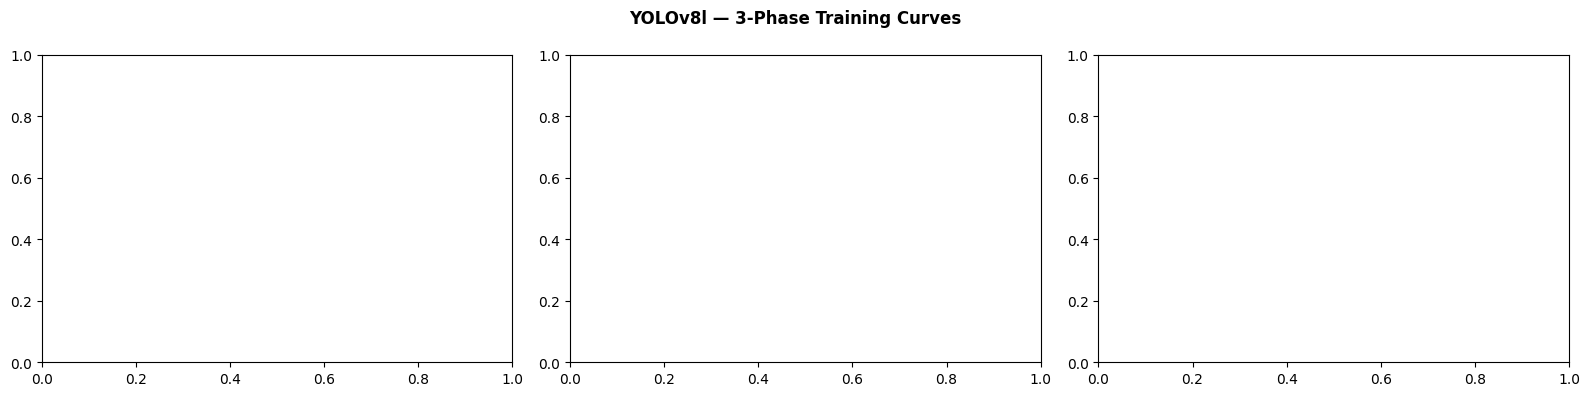

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('YOLOv8l — 3-Phase Training Curves', fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71']
for i, (phase, run_name) in enumerate([
    ('Phase 1', 'p1_warmup'),
    ('Phase 2', 'p2_finetune'),
    ('Phase 3', 'p3_highres'),
]):
    csv = Path(f'/content/runs/{run_name}/results.csv')
    if not csv.exists():
        continue
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    if 'metrics/mAP50(B)' in df.columns:
        axes[i].plot(df['epoch'], df['metrics/mAP50(B)'], color=colors[i], label='mAP@50')
        axes[i].axhline(0.70, color='red', linestyle='--', alpha=0.5, label='target')
    axes[i].set_title(phase)
    axes[i].set_xlabel('epoch')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

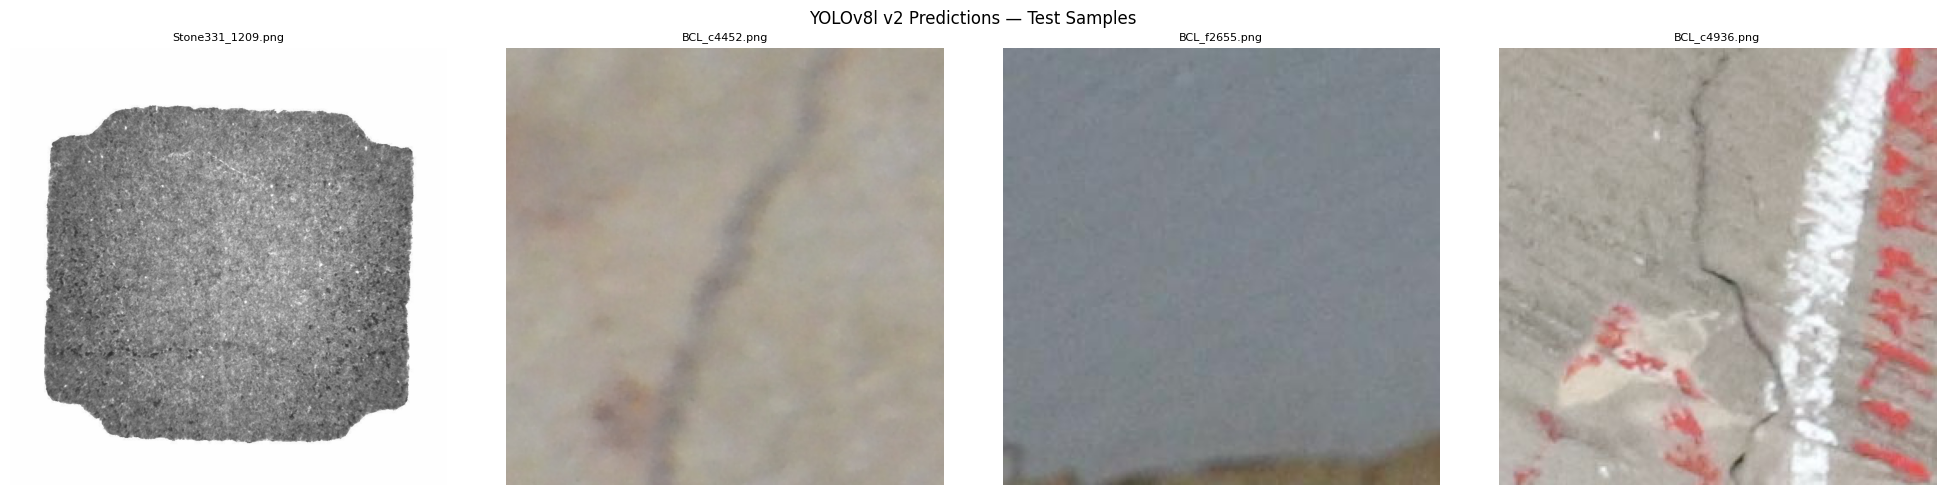

In [24]:
import random, cv2

sample_imgs = random.sample(test_imgs, min(4, len(test_imgs)))
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('YOLOv8l v2 Predictions — Test Samples')

for ax, img_path in zip(axes, sample_imgs):
    result    = best_model.predict(str(img_path), conf=0.25, imgsz=1280, verbose=False)[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/predictions_sample.png', dpi=150)
plt.show()

## 9. Save to Drive

In [26]:
import json as _json

DRIVE_PLOTS = DRIVE_DIR / 'plots' / 'detector_v2'
DRIVE_PLOTS.mkdir(parents=True, exist_ok=True)

for f in ['/content/training_curves.png', '/content/predictions_sample.png']:
    p = Path(f)
    if p.exists():
        shutil.copy2(p, DRIVE_PLOTS / p.name)

summary = {
      'test_map50':   float(metrics.box.map50),
      'test_map50_95': float(metrics.box.map),
      'precision':    float(metrics.box.mp),
      'recall':       float(metrics.box.mr),
  }
(DRIVE_CKPT / 'metrics.json').write_text(_json.dumps(summary, indent=2))

print('Saved to Drive:')
for f in sorted(DRIVE_CKPT.iterdir()):
    print(f'  {f.name:30s}  {f.stat().st_size/1e6:.1f} MB')

print(f'\n=== Final Summary ===')
print(f'  Model      : YOLOv8l')
print(f'  Training   : 20ep@640 + 30ep@640 + eval@1280')
print(f'  mAP@50     : {metrics.box.map50:.4f}  (was 0.3459)')
print(f'  mAP@50-95  : {metrics.box.map:.4f}  (was 0.1007)')
print(f'  Precision  : {metrics.box.mp:.4f}')
print(f'  Recall     : {metrics.box.mr:.4f}')

Saved to Drive:
  metrics.json                    0.0 MB
  p1_best.pt                      87.6 MB
  p2_best.pt                      87.6 MB

=== Final Summary ===
  Model      : YOLOv8l
  Training   : 20ep@640 + 30ep@640 + eval@1280
  mAP@50     : 0.0899  (was 0.3459)
  mAP@50-95  : 0.0537  (was 0.1007)
  Precision  : 0.2027
  Recall     : 0.2092
